In [82]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [83]:
df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

In [84]:
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [85]:
df_test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [86]:
df_train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [87]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [88]:
women = df_train.loc[df_train['Sex'] == 'female']['Survived']
survived_women = sum(women)/len(women)
men = df_train.loc[df_train['Sex'] == 'male']['Survived']
survived_men = sum(men) / len(men)
survived_men, survived_women

(0.18890814558058924, 0.7420382165605095)

In [89]:
df_test.Fare.fillna(df_test.Fare.mean(), inplace=True)

C:\Users\avera\AppData\Local\Temp\ipykernel_29540\3382210107.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_test.Fare.fillna(df_test.Fare.mean(), inplace=True)


In [90]:
x = df_train.drop(['Age','Survived', 'Name', 'Ticket', 'Cabin', 'PassengerId', 'Embarked'], axis=1)
y = df_train['Age']


x_age_test = df_test.drop(['Age', 'Name', 'Ticket', 'Cabin', 'PassengerId', 'Embarked'], axis=1)
y_age_test = df_test['Age']

x_age_test = pd.get_dummies(x_age_test, columns=['Sex'], drop_first=True)  
x = pd.get_dummies(x, columns=['Sex'], drop_first=True)

In [91]:
x_train_age = x[df_train['Age'].notnull()]
y_train_age = y[df_train['Age'].notnull()]

x_missing_age = x[df_train['Age'].isnull()]

In [92]:
x_test_age = x_age_test[df_test['Age'].notnull()]
y_test_age = y_age_test[df_test['Age'].notnull()]

x_missing_test_age = x_age_test[df_test['Age'].isnull()]

In [93]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_age_scaled = scaler.fit_transform(x_train_age)
x_missing_age_scaled = scaler.transform(x_missing_age)

In [94]:
x_test_age_scaled = scaler.fit_transform(x_test_age)
x_missing_test_age_scaled = scaler.transform(x_missing_test_age)

In [95]:
from sklearn.neighbors import KNeighborsRegressor
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(x_train_age_scaled, y_train_age)
predicted_ages = knn.predict(x_missing_age_scaled)
df_train.loc[df_train['Age'].isnull(), 'Age'] = predicted_ages

In [96]:
knn.fit(x_test_age_scaled, y_test_age)
predicted_test_ages = knn.predict(x_missing_test_age_scaled)
df_test.loc[df_test['Age'].isnull(), 'Age'] = predicted_test_ages

In [97]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          418 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         418 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


In [98]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [99]:
x_train = df_train.drop(['Survived', 'Name', 'Ticket', 'Cabin', 'PassengerId', 'Embarked'], axis=1)
y_train = df_train.loc[:, 'Survived']
x_test = df_test.drop(['Name', 'Ticket', 'Cabin', 'PassengerId', 'Embarked'], axis=1)

In [100]:
x_train = pd.get_dummies(x_train, columns=['Sex'], drop_first=True)
x_test = pd.get_dummies(x_test, columns=['Sex'], drop_first=True)

<Axes: >

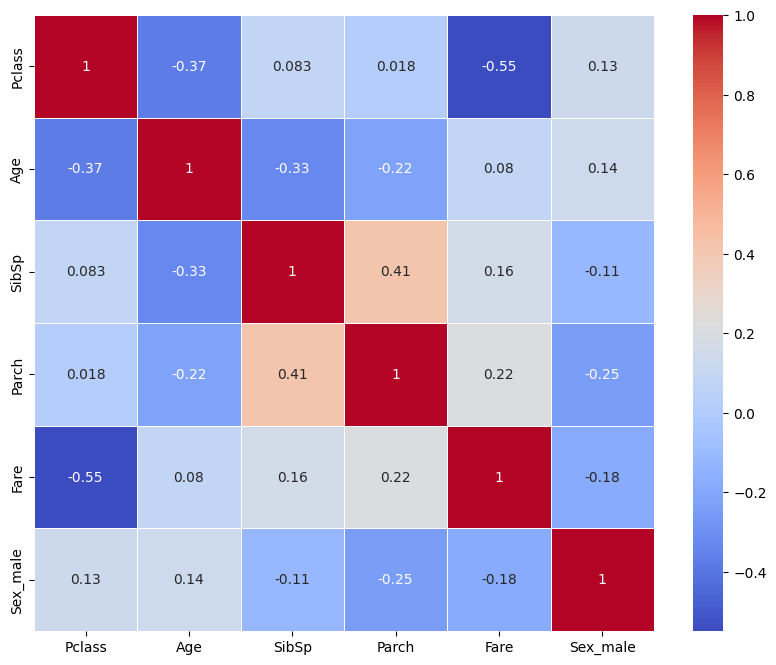

In [101]:
df_corr = x_train.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(df_corr, annot=True, cmap='coolwarm', linewidths=0.5)

In [112]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
model_xgb = xgb.XGBClassifier(random_state=42)
param_grid = {
    'n_estimators': [100, 150, 200, 300],
    'max_depth': [3, 4, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2, 0.3], 
    'reg_alpha': [0, 0.1, 0.5, 1]
}


In [103]:
grid_search = GridSearchCV(estimator=model_xgb, param_grid=param_grid, cv=5, scoring='f1_macro', n_jobs=-1)
grid_search.fit(x_train, y_train)

,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'learning_rate': [0.01, 0.1, ...], 'max_depth': [3, 4, ...], 'n_estimators': [100, 150, ...], 'reg_alpha': [0, 0.1, ...]}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'binary:logistic'


In [109]:
grid_search.feature_names_in_

array(['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male'], dtype='<U8')

In [114]:
model_xgb.fit(x_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [115]:
model_xgb.feature_importances_

array([0.19458006, 0.03719766, 0.0682824 , 0.03067024, 0.0375428 ,
       0.63172686], dtype=float32)

In [104]:
y_pred_train = grid_search.predict(x_train)

In [105]:
y_pred_xgb = grid_search.predict(x_test)

In [106]:
best_params = grid_search.best_params_
print("Best Hyperparameters:", best_params)

Best Hyperparameters: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 100, 'reg_alpha': 0.5}


In [107]:
from sklearn.metrics import classification_report, confusion_matrix
print("Classification Report:\n", classification_report(y_train, y_pred_train))
print("Confusion Matrix:\n", confusion_matrix(y_train, y_pred_train))

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.94      0.91       549
           1       0.89      0.82      0.85       342

    accuracy                           0.89       891
   macro avg       0.89      0.88      0.88       891
weighted avg       0.89      0.89      0.89       891

Confusion Matrix:
 [[514  35]
 [ 63 279]]


In [108]:
output = pd.DataFrame({'PassengerId': df_test.PassengerId, 'Survived': y_pred_xgb})
output.to_csv('submission.csv', index=False)
print("Your submission was successfully saved!")


Your submission was successfully saved!
